# Chapter 0 — Bayesian model and validation

This notebook develops and checks the Bayesian model used in the dissertation.

The general framework allows both symmetric and one-sided label corruption. The experiments below focus on one-sided $1\to0$ corruption, which is the mechanism used in the later simulation and applied studies.

For observation $i$,

$$
y_i' \mid \mathbf{x}_i
\sim
\operatorname{Bernoulli}(p_i),
\qquad
\operatorname{logit}(p_i)
=
\beta_0+\boldsymbol{\beta}^{\top}\mathbf{x}_i,
$$

where $y_i'$ is the unobserved true response.

Corruption occurs within a region

$$
R=\{\mathbf{x}:\boldsymbol{\alpha}^{\top}\mathbf{x}>c\}.
$$

Under symmetric corruption, either class may flip inside $R$:

$$
z_i\mid\mathbf{x}_i
\sim
\operatorname{Bernoulli}
\left(
q\,\mathbb{1}\{\mathbf{x}_i\in R\}
\right),
$$

$$
y_i=z_i(1-y_i')+(1-z_i)y_i'.
$$

Under one-sided $1\to0$ corruption, only latent positives may be corrupted:

$$
z_i\mid y_i',\mathbf{x}_i
\sim
\begin{cases}
\operatorname{Bernoulli}(q), & y_i'=1,\ \mathbf{x}_i\in R,\\
0, & \text{otherwise},
\end{cases}
$$

with

$$
y_i=(1-z_i)y_i'.
$$

The probabilistic model is kept fixed. The validation cases below change the simulated data-generating setting to see when recovery becomes easier or harder.


> **High-replication safe version:** the original validation examples remain as detailed illustrative fits. In addition, Configurations A and B and the soft-boundary sensitivity check are repeated across 20 independently generated datasets to quantify between-dataset variability. The learned-boundary validation remains illustrative here because its systematic replication is handled in Chapter 1.

## Final notebook note

Framework validation and controlled checks of the Bayesian model. The numerical definitions, seeds, fitted models and stored results are unchanged.

The notebook has only been lightly polished for readability and consistency. No model definitions, experimental settings, random seeds, calculations or existing figure filenames have been changed.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from cleanlab.filter import find_label_issues

try:
    from cmdstanpy import CmdStanModel
    STAN_AVAILABLE = True
    print('Stan available — will run full MCMC')
except ImportError:
    STAN_AVAILABLE = False
    print('Stan not available.')

SEED = 42


Stan available — will run full MCMC


In [ ]:

from pathlib import Path
import pandas as pd
import gc

# Safe high-replication output area. Existing dissertation artefacts are
# not intentionally overwritten by this notebook.
HIGHREP_ROOT = Path("high_replication") / "chapter0"
FIG_DIR = HIGHREP_ROOT / "figures"
RESULT_DIR = HIGHREP_ROOT / "results"
STAN_DIR = HIGHREP_ROOT / "stan"
CHECKPOINT_DIR = RESULT_DIR / "replicate_checkpoints"

for folder in [FIG_DIR, RESULT_DIR, STAN_DIR, CHECKPOINT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

AXIS_STAN = STAN_DIR / "corruption_model_axis_FINAL.stan"
GENERAL_STAN = STAN_DIR / "corruption_model_general_FINAL.stan"

print("Chapter 0 safe output root:", HIGHREP_ROOT.resolve())


In [2]:
# Shared dissertation plotting conventions
# These settings only standardise typography and output quality.
# They do not change the data, fitted models, estimands or figure filenames.

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.titleweight": "normal",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
    "lines.linewidth": 1.8,
    "lines.markersize": 5.5,
    "errorbar.capsize": 3,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
})


## Hard boundary and HMC approximation

The simulated corruption mechanism uses the hard region

$$
R=\{\mathbf{x}:\boldsymbol{\alpha}^{\top}\mathbf{x}>c\}.
$$

For HMC inference, region membership is approximated by

$$
r_i=
\sigma\left(
\kappa(\boldsymbol{\alpha}^{\top}\mathbf{x}_i-c)
\right),
$$

so the effective corruption probability is $w_i=q\,r_i$.

The hard boundary is still the scientific model. The sigmoid is only a computational approximation: the hard indicator changes abruptly as the boundary crosses observations and gives little useful local gradient information between those crossings.

The main fits use $\kappa=5$, with sensitivity checked later.


## Stan model

The discrete latent quantities are marginalised rather than sampled directly.

For symmetric corruption,

$$
P(y_i=1\mid\mathbf{x}_i)
=
(1-w_i)p_i+w_i(1-p_i).
$$

For the one-sided model used below,

$$
P(y_i=1\mid\mathbf{x}_i)=p_i(1-w_i),
$$

and

$$
P(y_i=0\mid\mathbf{x}_i)
=
(1-p_i)+p_iw_i.
$$

For an observed negative,

$$
P(z_i=1\mid y_i=0,\mathbf{x}_i,\theta)
=
\frac{w_i p_i}{(1-p_i)+w_i p_i}.
$$

Observed positives have posterior corruption probability zero under the one-sided mechanism.

The Stan implementation uses weakly informative priors

$$
\beta_0\sim\mathcal{N}(0,2^2),
\qquad
\beta_j\sim\mathcal{N}(0,1),
$$

$$
c\sim\mathcal{N}(c_0,s_c^2),
\qquad
q\sim\operatorname{Beta}(2,5).
$$

For the simulation fits below, $c_0=0$ and $s_c=1$, so the prior is not centred at the generating threshold.


In [3]:
stan_code = r'''
/*
  Structured Label Corruption Model v6 — Soft Boundary, One-Sided (1 -> 0)
  ========================================================================
  Corruption mechanism (underdiagnosis): a true positive inside the
  region is recorded as negative with probability q. Negatives are
  never flipped. Changes from v5:

  1. Direction: likelihood matches the 1->0 operator used in
     Chapters 1 and 2:
        P(y = 1 | x) = (1 - q r) p
        P(y = 0 | x) = (1 - p) + q r p
     with p = inv_logit(beta0 + x.beta), r = inv_logit(kappa (x_b - c)).
     Under this mechanism z_i = 1 is only possible when y_i = 0.
  2. Intercept beta0 added (the DGP has one; omitting it biases
     beta, c and q).
  3. Corruption terms computed on the log scale via log_inv_logit
     for numerical stability far from the boundary.
  4. c prior centre AND sd passed as data — the centre must not be
     set to the simulation truth (that would be circular).
  5. log_lik in generated quantities for LOO/WAIC.
*/

data {
  int<lower=0> n;
  int<lower=0> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;
  int<lower=1, upper=p> boundary_dim;
  real kappa;              // boundary sharpness (fixed; sensitivity in Sec. 8)
  real c_prior_mean;
  real<lower=0> c_prior_sd;
}

parameters {
  real beta0;
  vector[p] beta;
  real c;
  real<lower=0, upper=1> q;
}

model {
  beta0 ~ normal(0, 2);
  beta  ~ normal(0, 1);
  c     ~ normal(c_prior_mean, c_prior_sd);
  q     ~ beta(2, 5);

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);      // log P(y' = 1 | x)
      real log_1p = log1m_inv_logit(eta[i]);    // log P(y' = 0 | x)
      real log_qr = log(q) + log_r[i];          // log P(z = 1 | x)
      if (y[i] == 1) {
        // observed positive: must be a clean true positive
        target += log1m_exp(log_qr) + log_p;
      } else {
        // observed negative: true negative OR hidden (corrupted) positive
        target += log_sum_exp(log_1p, log_qr + log_p);
      }
    }
  }
}

generated quantities {
  vector[n] z_prob;   // P(z_i = 1 | y_i, theta); zero by construction when y_i = 1
  vector[n] r;
  vector[n] log_lik;
  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X[, boundary_dim] - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];
      r[i] = exp(log_r[i]);
      if (y[i] == 1) {
        z_prob[i]  = 0;
        log_lik[i] = log1m_exp(log_qr) + log_p;
      } else {
        real log_corr = log_qr + log_p;
        real log_tot  = log_sum_exp(log_1p, log_corr);
        z_prob[i]  = exp(log_corr - log_tot);
        log_lik[i] = log_tot;
      }
    }
  }
}
'''
with open(AXIS_STAN, 'w') as f:
    f.write(stan_code)
print(f'Axis Stan model written safely to {AXIS_STAN}')


corruption_model_axis_FINAL.stan written to disk.


## Bayesian recovery checks

The baseline simulation uses $p=5$ independent standard normal covariates and

$$
\beta_0=-0.8,
\qquad
\boldsymbol{\beta}=(1.5,-1.2,0.8,-0.6,0).
$$

The fifth covariate is therefore null in the latent response model. Labels are corrupted with the hard one-sided $1\to0$ mechanism at $q=0.35$.

Three controlled settings are used to check the behaviour of the Bayesian implementation under known synthetic truth:

- **A:** the boundary is placed on the null covariate, $x_5>0.8$, giving a relatively favourable setting in which the boundary direction does not contribute to the latent response;
- **B:** the same threshold and corruption rate are used, but the boundary is placed on the strongest response predictor, $x_1>0.8$, introducing overlap between the response and corruption mechanisms;
- **C:** the boundary direction is no longer supplied to the model and must be estimated, with an oblique true direction proportional to $(0,0,0,1,1)$.

These are deliberately constructed recovery checks rather than a systematic simulation study. The broader effects of corruption rate, region size, dimensionality and response--corruption alignment are investigated in Chapter 1.


In [4]:
def logistic_dgp(n, rng, p=5):
    X = rng.normal(0, 1, (n, p))
    w = np.zeros(p)
    w[:min(4, p)] = [1.5, -1.2, 0.8, -0.6][:min(4, p)]
    prob = 1 / (1 + np.exp(-(-0.8 + X @ w)))
    return X, rng.binomial(1, prob).astype(int), w


def corrupt(y, region_mask, p_in, seed=0):
    """Directional corruption — 1->0 only (underdiagnosis). p_out = 0."""
    r = np.random.default_rng(seed)
    y_c = y.copy()
    flip_mask = (y == 1) & (r.random(len(y)) < np.where(region_mask, p_in, 0.0))
    y_c[flip_mask] = 0
    return y_c, flip_mask


P_SIM, N_SIM, P_IN, TRUE_C = 5, 1500, 0.35, 0.8

rng = np.random.default_rng(SEED)
X_sim, y_true_sim, w_true = logistic_dgp(N_SIM, rng, p=P_SIM)

configs = {
    'A (null boundary, x4)':      {'dim': 4},
    'B (predictive boundary, x0)': {'dim': 0},
}
for name, cfg in configs.items():
    d = cfg['dim']
    cfg['region'] = X_sim[:, d] > TRUE_C
    cfg['y_corr'], cfg['flips'] = corrupt(y_true_sim, cfg['region'], P_IN, seed=SEED + d)
    print(f'Config {name}: region {cfg["region"].mean()*100:.1f}% of data | '
          f'eligible (y=1 in region) {(cfg["region"] & (y_true_sim==1)).sum()} | '
          f'corrupted {cfg["flips"].sum()} ({cfg["flips"].mean()*100:.1f}% of all labels)')


Config A (null boundary, x4): region 19.7% of data | eligible (y=1 in region) 126 | corrupted 44 (2.9% of all labels)
Config B (predictive boundary, x0): region 21.1% of data | eligible (y=1 in region) 208 | corrupted 64 (4.3% of all labels)


In [5]:
def hard_halfspace(X, alpha, c):
    """Return membership in R = {x : alpha^T x > c}, normalising alpha."""
    X = np.asarray(X, dtype=float)
    alpha = np.asarray(alpha, dtype=float)

    norm = np.linalg.norm(alpha)
    if norm <= 0:
        raise ValueError("alpha must have non-zero norm.")

    alpha = alpha / norm
    return (X @ alpha) > c


def corrupt_one_sided(y_true, region, q, rng):
    """Apply one-sided 1 -> 0 corruption inside a supplied region."""
    y_true = np.asarray(y_true, dtype=int)
    region = np.asarray(region, dtype=bool)

    if len(y_true) != len(region):
        raise ValueError("y_true and region must have the same length.")
    if not 0 <= q <= 1:
        raise ValueError("q must lie in [0, 1].")

    eligible = (y_true == 1) & region
    flips = eligible & (rng.random(len(y_true)) < q)

    y_obs = y_true.copy()
    y_obs[flips] = 0
    return y_obs, flips


def corrupt_symmetric(y_true, region, q, rng):
    """Apply symmetric label flipping inside a supplied region."""
    y_true = np.asarray(y_true, dtype=int)
    region = np.asarray(region, dtype=bool)

    if len(y_true) != len(region):
        raise ValueError("y_true and region must have the same length.")
    if not 0 <= q <= 1:
        raise ValueError("q must lie in [0, 1].")

    flips = region & (rng.random(len(y_true)) < q)
    y_obs = y_true.copy()
    y_obs[flips] = 1 - y_obs[flips]
    return y_obs, flips


## Configuration A — supplied boundary on a null predictor

The first fit uses

$$
R=\{\mathbf{x}:x_5>0.8\}.
$$

The boundary direction is supplied to the model, so the main checks are recovery of the threshold $c$, corruption rate $q$, latent response coefficients, and observation-level corruption probabilities.


In [6]:
KAPPA = 5.0

def fit_stan(X, y_corr, boundary_dim, kappa=KAPPA, seed=SEED):
    """boundary_dim is 0-indexed here; converted to Stan's 1-indexing."""
    stan_data = {
        'n': len(y_corr), 'p': X.shape[1],
        'X': X.tolist(), 'y': y_corr.tolist(),
        'boundary_dim': boundary_dim + 1,
        'kappa': kappa,
        'c_prior_mean': 0.0,   # weakly informative — NOT centred at the truth
        'c_prior_sd': 1.0,
    }
    fit = model.sample(data=stan_data, chains=4, parallel_chains=4,
                       iter_warmup=1000, iter_sampling=2000, seed=seed,
                       adapt_delta=0.95, max_treedepth=12, show_progress=True)
    return fit


def summarise_fit(fit, X, y_corr, flips, region, boundary_dim, label):
    print(f'\n===== {label} =====')
    print(fit.diagnose())
    beta0 = fit.stan_variable('beta0'); beta = fit.stan_variable('beta')
    c_post = fit.stan_variable('c');    q_post = fit.stan_variable('q')
    z_mean = fit.stan_variable('z_prob').mean(axis=0)
    r_mean = fit.stan_variable('r').mean(axis=0)

    print('Posterior summaries (true values in brackets):')
    print(f'  beta0 [{-0.8:+.2f}]: mean={beta0.mean():+.3f} '
          f'95% CI [{np.percentile(beta0,2.5):+.3f}, {np.percentile(beta0,97.5):+.3f}]')
    for j in range(X.shape[1]):
        print(f'  beta[{j}] [{w_true[j]:+.2f}]: mean={beta[:,j].mean():+.3f} '
              f'95% CI [{np.percentile(beta[:,j],2.5):+.3f}, {np.percentile(beta[:,j],97.5):+.3f}]')
    print(f'  c [{TRUE_C:+.2f}]: mean={c_post.mean():+.3f} '
          f'95% CI [{np.percentile(c_post,2.5):+.3f}, {np.percentile(c_post,97.5):+.3f}]')
    print(f'  q [{P_IN:+.2f}]: mean={q_post.mean():+.3f} '
          f'95% CI [{np.percentile(q_post,2.5):+.3f}, {np.percentile(q_post,97.5):+.3f}]')

    neg = (y_corr == 0)   # only observed negatives can be corrupted
    print('\nLocalisation (among observed negatives, where corruption can occur):')
    print(f'  mean z_prob — truly corrupted: {z_mean[flips].mean():.3f}')
    print(f'  mean z_prob — clean negatives: {z_mean[neg & ~flips].mean():.3f}')
    print(f'  ranked AUC of z_prob vs true corruption (negatives only): '
          f'{roc_auc_score(flips[neg], z_mean[neg]):.3f}')
    print(f'  r — inside region:  {r_mean[region].mean():.3f} | '
          f'outside: {r_mean[~region].mean():.3f}')
    return {'beta0': beta0, 'beta': beta, 'c': c_post, 'q': q_post,
            'z_mean': z_mean, 'r_mean': r_mean}


if STAN_AVAILABLE:
    print('Compiling Stan model v6...')
    model = CmdStanModel(stan_file=str(AXIS_STAN))
    cfgA = configs['A (null boundary, x4)']
    fitA = fit_stan(X_sim, cfgA['y_corr'], boundary_dim=4)
    resA = summarise_fit(fitA, X_sim, cfgA['y_corr'], cfgA['flips'],
                         cfgA['region'], 4, 'Configuration A — null boundary (x4)')


14:54:28 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmplyrgfq08/tmpttykhs91.stan to exe file /Users/demikramer/Desktop/MLDS - LATEST FINAL OFFICIAL/corruption_model_axis_FINAL


Compiling Stan model v6...


14:54:33 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/MLDS - LATEST FINAL OFFICIAL/corruption_model_axis_FINAL
14:54:33 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

14:54:42 - cmdstanpy - INFO - CmdStan done processing.




===== Configuration A — null boundary (x4) =====
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior summaries (true values in brackets):
  beta0 [-0.80]: mean=-0.736 95% CI [-0.901, -0.566]
  beta[0] [+1.50]: mean=+1.370 95% CI [+1.182, +1.570]
  beta[1] [-1.20]: mean=-1.211 95% CI [-1.391, -1.040]
  beta[2] [+0.80]: mean=+0.740 95% CI [+0.577, +0.907]
  beta[3] [-0.60]: mean=-0.494 95% CI [-0.644, -0.351]
  beta[4] [+0.00]: mean=+0.002 95% CI [-0.181, +0.184]
  c [+0.80]: mean=+0.847 95% CI [+0.452, +1.157]
  q [+0.35]: mean=+0.361 95% CI [+0.202, +0.524]

Localisation (among observed negatives

### Configuration A posterior checks

The plots below compare posterior distributions with the generating values and show the posterior corruption probabilities for observed negatives.

This is the favourable validation case because the supplied boundary variable does not contribute to the latent response model.


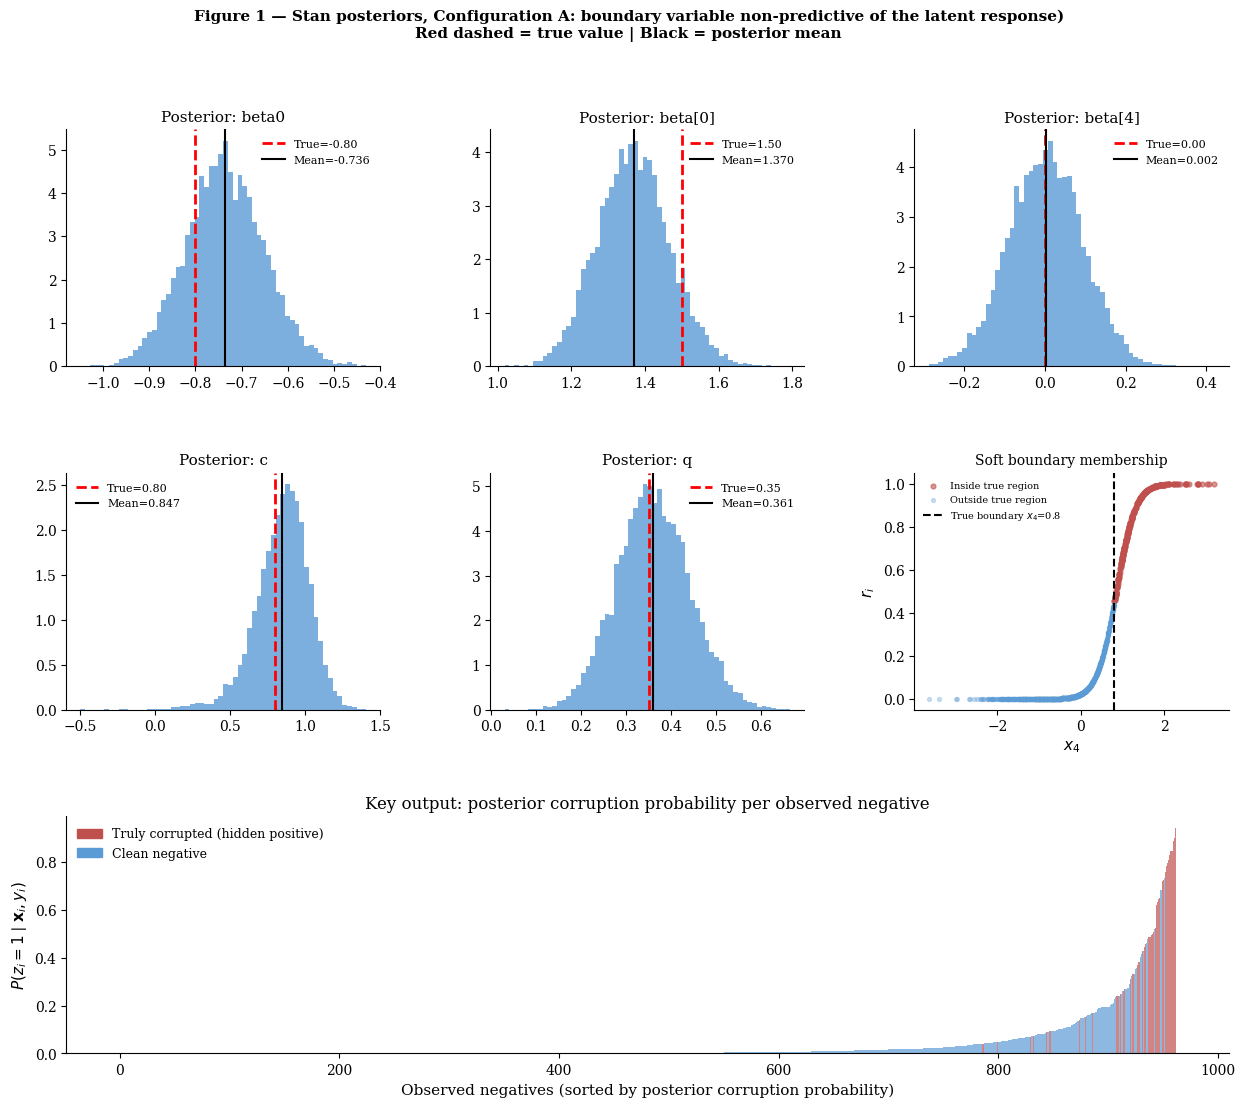

In [16]:
# Safe high-replication version: existing dissertation artefacts are left untouched.
if STAN_AVAILABLE:
    cfg, res = cfgA, resA
    neg = cfg['y_corr'] == 0
    fig = plt.figure(figsize=(15, 12))
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

    panels = [('beta0', res['beta0'], -0.8),
              ('beta[0]', res['beta'][:, 0], w_true[0]),
              ('beta[4]', res['beta'][:, 4], w_true[4]),
              ('c', res['c'], TRUE_C),
              ('q', res['q'], P_IN)]
    for k, (name, s, tv) in enumerate(panels):
        ax = fig.add_subplot(gs[k // 3, k % 3])
        ax.hist(s, bins=60, color='#5B9BD5', alpha=0.8, density=True)
        ax.axvline(tv, color='red', lw=2, ls='--', label=f'True={tv:.2f}')
        ax.axvline(s.mean(), color='black', lw=1.5, label=f'Mean={s.mean():.3f}')
        ax.set_title(f'Posterior: {name}', fontsize=11)
        ax.legend(fontsize=8, frameon=False)

    ax = fig.add_subplot(gs[1, 2])
    ax.scatter(X_sim[cfg['region'], 4], res['r_mean'][cfg['region']],
               c='#C0504D', alpha=0.6, s=12, label='Inside true region')
    ax.scatter(X_sim[~cfg['region'], 4], res['r_mean'][~cfg['region']],
               c='#5B9BD5', alpha=0.3, s=8, label='Outside true region')
    ax.axvline(TRUE_C, color='black', ls='--', lw=1.5, label=f'True boundary $x_4$={TRUE_C}')
    ax.set_xlabel('$x_4$'); ax.set_ylabel(r'$r_i$')
    ax.set_title('Soft boundary membership', fontsize=10)
    ax.legend(fontsize=7, frameon=False)

    ax = fig.add_subplot(gs[2, :])
    idx_neg = np.where(neg)[0]
    order = idx_neg[np.argsort(res['z_mean'][idx_neg])]
    cols = ['#C0504D' if cfg['flips'][i] else '#5B9BD5' for i in order]
    ax.bar(range(len(order)), res['z_mean'][order], color=cols, alpha=0.7, width=1.0)
    rp = plt.matplotlib.patches.Patch(color='#C0504D', label='Truly corrupted (hidden positive)')
    bp = plt.matplotlib.patches.Patch(color='#5B9BD5', label='Clean negative')
    ax.legend(handles=[rp, bp], frameon=False, fontsize=9)
    ax.set_xlabel('Observed negatives (sorted by posterior corruption probability)')
    ax.set_ylabel(r'$P(z_i=1 \mid \mathbf{x}_i, y_i)$')
    ax.set_title('Key output: posterior corruption probability per observed negative')

    fig.suptitle('Figure 1 — Stan posteriors, Configuration A: boundary variable non-predictive of the latent response)\n'
                 'Red dashed = true value | Black = posterior mean',
                 fontsize=11, fontweight='bold')
    # The "Figure 1 — Stan posteriors, Configuration A" cell:
    fig.savefig(FIG_DIR / 'highrep_reference_bayes_configA.png', dpi=200, bbox_inches='tight')
    plt.show()


## Configuration B — supplied boundary on a response predictor

The boundary is moved to

$$
R=\{\mathbf{x}:x_1>0.8\}.
$$

Because $x_1$ is strongly predictive of the latent response, the response and corruption mechanisms can explain similar changes in the observed labels.

The model itself is unchanged. This configuration tests how response--corruption confounding affects recovery and localisation.


14:55:01 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

14:55:10 - cmdstanpy - INFO - CmdStan done processing.




===== Configuration B — predictive boundary (x0) =====
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Posterior summaries (true values in brackets):
  beta0 [-0.80]: mean=-0.696 95% CI [-0.865, -0.524]
  beta[0] [+1.50]: mean=+1.599 95% CI [+1.319, +1.890]
  beta[1] [-1.20]: mean=-1.349 95% CI [-1.547, -1.161]
  beta[2] [+0.80]: mean=+0.826 95% CI [+0.655, +1.003]
  beta[3] [-0.60]: mean=-0.518 95% CI [-0.679, -0.363]
  beta[4] [+0.00]: mean=+0.034 95% CI [-0.120, +0.186]
  c [+0.80]: mean=+0.891 95% CI [+0.655, +1.119]
  q [+0.35]: mean=+0.403 95% CI [+0.300, +0.508]

Localisation (among observed neg

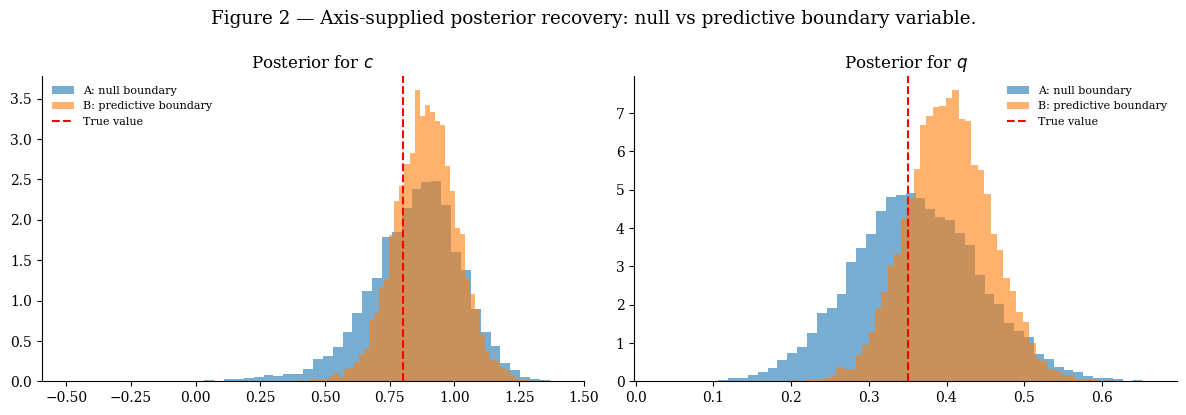

In [8]:
# Safe high-replication version: existing dissertation artefacts are left untouched.
if STAN_AVAILABLE:
    cfgB = configs['B (predictive boundary, x0)']
    fitB = fit_stan(X_sim, cfgB['y_corr'], boundary_dim=0)
    resB = summarise_fit(fitB, X_sim, cfgB['y_corr'], cfgB['flips'],
                         cfgB['region'], 0, 'Configuration B — predictive boundary (x0)')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for ax, par, tv in [(axes[0], 'c', TRUE_C), (axes[1], 'q', P_IN)]:
        ax.hist(resA[par], bins=50, alpha=0.6, density=True, label='A: null boundary')
        ax.hist(resB[par], bins=50, alpha=0.6, density=True, label='B: predictive boundary')
        ax.axvline(tv, color='red', ls='--', lw=1.5, label='True value')
        ax.set_title(f'Posterior for ${par}$'); ax.legend(fontsize=8, frameon=False)
    fig.suptitle('Figure 2 — Axis-supplied posterior recovery: null vs predictive boundary variable.')
    plt.tight_layout(); plt.show()


In [9]:
stan_code_v7 = r'''
/*
  Structured Label Corruption Model v7 — General Hyperplane Boundary
  ===================================================================
  Extension of v6: the corruption boundary is a general hyperplane
      R = { x : alpha . x > c },   ||alpha|| = 1,
  with the full normal vector alpha estimated jointly with (beta0, beta, c, q).
  This implements the supervisor's specification with alpha in R^p, rather
  than fixing the boundary axis as domain knowledge.

  Identifiability notes:
  - ||alpha|| = 1 fixes the scale non-identifiability of (alpha, c).
    Implemented via the normalized-vector trick: alpha_raw ~ normal(0, 1),
    alpha = alpha_raw / ||alpha_raw||. With an isotropic Gaussian prior
    on alpha_raw this induces no preferred orientation.
  - There is no sign/reflection ambiguity for the region itself:
    {x : alpha.x > c} and {x : -alpha.x > -c} are complementary halfspaces,
    not the same set. These constraints remove parameterisation ambiguity;
    practical recovery from finite data is assessed empirically below.
  - Everything else (one-sided 1->0 likelihood, soft boundary, marginalised
    latents, closed-form z_prob, log_lik) matches v6.
*/

data {
  int<lower=0> n;
  int<lower=0> p;
  matrix[n, p] X;
  array[n] int<lower=0, upper=1> y;
  real kappa;              // soft-boundary steepness (fixed)
  real c_prior_mean;
  real<lower=0> c_prior_sd;
}

parameters {
  real beta0;
  vector[p] beta;
  vector[p] alpha_raw;     // unnormalised boundary normal
  real c;
  real<lower=0, upper=1> q;
}

transformed parameters {
  vector[p] alpha = alpha_raw / norm2(alpha_raw);
}

model {
  beta0     ~ normal(0, 2);
  beta      ~ normal(0, 1);
  alpha_raw ~ normal(0, 1);      // induces uniform prior on the unit sphere
  c         ~ normal(c_prior_mean, c_prior_sd);
  q         ~ beta(2, 5);

  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X * alpha - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);      // log P(y' = 1 | x)
      real log_1p = log1m_inv_logit(eta[i]);    // log P(y' = 0 | x)
      real log_qr = log(q) + log_r[i];          // log P(z = 1 | x)
      if (y[i] == 1) {
        target += log1m_exp(log_qr) + log_p;
      } else {
        target += log_sum_exp(log_1p, log_qr + log_p);
      }
    }
  }
}

generated quantities {
  vector[n] z_prob;
  vector[n] r;
  vector[n] log_lik;
  {
    vector[n] eta   = beta0 + X * beta;
    vector[n] log_r = log_inv_logit(kappa * (X * alpha - c));
    for (i in 1:n) {
      real log_p  = log_inv_logit(eta[i]);
      real log_1p = log1m_inv_logit(eta[i]);
      real log_qr = log(q) + log_r[i];
      r[i] = exp(log_r[i]);
      if (y[i] == 1) {
        z_prob[i]  = 0;
        log_lik[i] = log1m_exp(log_qr) + log_p;
      } else {
        real log_corr = log_qr + log_p;
        real log_tot  = log_sum_exp(log_1p, log_corr);
        z_prob[i]  = exp(log_corr - log_tot);
        log_lik[i] = log_tot;
      }
    }
  }
}
'''
with open(GENERAL_STAN, 'w') as f:
    f.write(stan_code_v7)
print(f'General Stan model written safely to {GENERAL_STAN}')


corruption_model_general_FINAL.stan written to disk.


## General boundary model

The previous fits supply the relevant boundary direction. The general model instead estimates

$$
\boldsymbol{\alpha}
$$

jointly with $\boldsymbol{\beta}$, $c$ and $q$.

To remove the scale ambiguity of the halfspace,

$$
\boldsymbol{\alpha}
=
\frac{\boldsymbol{\alpha}_{\mathrm{raw}}}
{\|\boldsymbol{\alpha}_{\mathrm{raw}}\|_2},
$$

with an isotropic Gaussian prior on $\boldsymbol{\alpha}_{\mathrm{raw}}$.

This fixes the parameterisation but does not guarantee that the direction can be recovered from a finite sample. Configuration C therefore checks both geometric recovery and observation-level localisation when the boundary orientation is unknown.


In [10]:
# Config C: oblique boundary combining the fourth covariate
# (weaker response signal, beta=-0.6) and fifth covariate (null, beta=0)
alpha_C = np.array([0., 0., 0., 1., 1.]); alpha_C /= np.linalg.norm(alpha_C)
c_C = 0.85
region_C = X_sim @ alpha_C > c_C
y_corr_C, flips_C = corrupt(y_true_sim, region_C, P_IN, seed=SEED + 4)
print(f'Config C: region {region_C.mean()*100:.1f}% | '
      f'eligible {(region_C & (y_true_sim==1)).sum()} | '
      f'corrupted {flips_C.sum()} ({flips_C.mean()*100:.1f}%)')

model_gen = CmdStanModel(stan_file=str(GENERAL_STAN))

def fit_general(y_corr, kappa=5.0, seed=SEED):
    data = {'n': N_SIM, 'p': P_SIM, 'X': X_sim.tolist(), 'y': y_corr.tolist(),
            'kappa': kappa, 'c_prior_mean': 0.0, 'c_prior_sd': 1.0}
    return model_gen.sample(data=data, chains=4, parallel_chains=4,
                            iter_warmup=1000, iter_sampling=2000, seed=seed,
                            adapt_delta=0.95, max_treedepth=12, show_progress=False)

def summarise_general(fit, flips, y_corr, alpha_true, c_true, label):
    print(f'\n===== {label} =====')
    print(fit.diagnose())
    a = fit.stan_variable('alpha'); c_post = fit.stan_variable('c')
    q_post = fit.stan_variable('q'); z_mean = fit.stan_variable('z_prob').mean(axis=0)
    cos = a @ alpha_true                       # cosine similarity per draw (both unit norm)
    for j in range(a.shape[1]):
        print(f'  alpha[{j}] [{alpha_true[j]:+.3f}]: mean={a[:,j].mean():+.3f} '
              f'95% CI [{np.percentile(a[:,j],2.5):+.3f}, {np.percentile(a[:,j],97.5):+.3f}]')
    print(f'  c [{c_true:+.2f}]: mean={c_post.mean():+.3f} '
          f'95% CI [{np.percentile(c_post,2.5):+.3f}, {np.percentile(c_post,97.5):+.3f}]')
    print(f'  q [{P_IN:+.2f}]: mean={q_post.mean():+.3f} '
          f'95% CI [{np.percentile(q_post,2.5):+.3f}, {np.percentile(q_post,97.5):+.3f}]')
    print(f'  cosine(alpha_draw, alpha_true): mean={cos.mean():.3f} '
          f'5th pct={np.percentile(cos,5):.3f}')
    neg = y_corr == 0
    print(f'  localisation AUC (negatives only): {roc_auc_score(flips[neg], z_mean[neg]):.3f}')
    return {'alpha': a, 'c': c_post, 'q': q_post, 'z_mean': z_mean, 'cos': cos}

alpha_A_true = np.zeros(P_SIM); alpha_A_true[4] = 1.0
fitGA = fit_general(cfgA['y_corr'])
resGA = summarise_general(fitGA, cfgA['flips'], cfgA['y_corr'], alpha_A_true, TRUE_C,
                          'General alpha — Configuration A data (axis-aligned truth)')

fitGC = fit_general(y_corr_C, seed=SEED + 1)
resGC = summarise_general(fitGC, flips_C, y_corr_C, alpha_C, c_C,
                          'General alpha — Configuration C (oblique truth)')


14:55:28 - cmdstanpy - INFO - compiling stan file /var/folders/hk/s02zbvd931b5x94gx2t9sh940000gn/T/tmpyse239kn/tmpgzix7yea.stan to exe file /Users/demikramer/Desktop/MLDS - LATEST FINAL OFFICIAL/corruption_model_general_FINAL


Config C: region 19.6% | eligible 95 | corrupted 38 (2.5%)


14:55:33 - cmdstanpy - INFO - compiled model executable: /Users/demikramer/Desktop/MLDS - LATEST FINAL OFFICIAL/corruption_model_general_FINAL
14:55:33 - cmdstanpy - INFO - CmdStan start processing
14:55:33 - cmdstanpy - INFO - Chain [1] start processing
14:55:33 - cmdstanpy - INFO - Chain [2] start processing
14:55:33 - cmdstanpy - INFO - Chain [3] start processing
14:55:33 - cmdstanpy - INFO - Chain [4] start processing
14:55:53 - cmdstanpy - INFO - Chain [2] done processing
14:55:54 - cmdstanpy - INFO - Chain [1] done processing
14:55:57 - cmdstanpy - INFO - Chain [4] done processing
14:55:58 - cmdstanpy - INFO - Chain [3] done processing



===== General alpha — Configuration A data (axis-aligned truth) =====
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



14:56:17 - cmdstanpy - INFO - CmdStan start processing
14:56:17 - cmdstanpy - INFO - Chain [1] start processing
14:56:17 - cmdstanpy - INFO - Chain [2] start processing
14:56:17 - cmdstanpy - INFO - Chain [3] start processing
14:56:17 - cmdstanpy - INFO - Chain [4] start processing


  alpha[0] [+0.000]: mean=+0.392 95% CI [-0.221, +0.809]
  alpha[1] [+0.000]: mean=+0.221 95% CI [-0.405, +0.864]
  alpha[2] [+0.000]: mean=+0.135 95% CI [-0.495, +0.730]
  alpha[3] [+0.000]: mean=-0.132 95% CI [-0.682, +0.303]
  alpha[4] [+1.000]: mean=+0.581 95% CI [-0.075, +0.951]
  c [+0.80]: mean=+0.432 95% CI [-1.540, +1.578]
  q [+0.35]: mean=+0.267 95% CI [+0.123, +0.441]
  cosine(alpha_draw, alpha_true): mean=0.581 5th pct=0.075
  localisation AUC (negatives only): 0.928


14:56:41 - cmdstanpy - INFO - Chain [4] done processing
14:56:41 - cmdstanpy - INFO - Chain [2] done processing
14:56:44 - cmdstanpy - INFO - Chain [3] done processing
14:56:44 - cmdstanpy - INFO - Chain [1] done processing



===== General alpha — Configuration C (oblique truth) =====
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

  alpha[0] [+0.000]: mean=+0.391 95% CI [-0.417, +0.914]
  alpha[1] [+0.000]: mean=+0.278 95% CI [-0.615, +0.896]
  alpha[2] [+0.000]: mean=+0.004 95% CI [-0.741, +0.741]
  alpha[3] [+0.707]: mean=+0.052 95% CI [-0.739, +0.736]
  alpha[4] [+0.707]: mean=+0.097 95% CI [-0.710, +0.762]
  c [+0.85]: mean=+0.032 95% CI [-2.049, +2.079]
  q [+0.35]: mean=+0.180 95% CI [+0.055, +0.492]
  cosine(alpha_draw, alpha_true): mean=0.105 5th pct=-0.610
  localisation AUC (negatives only): 0.820


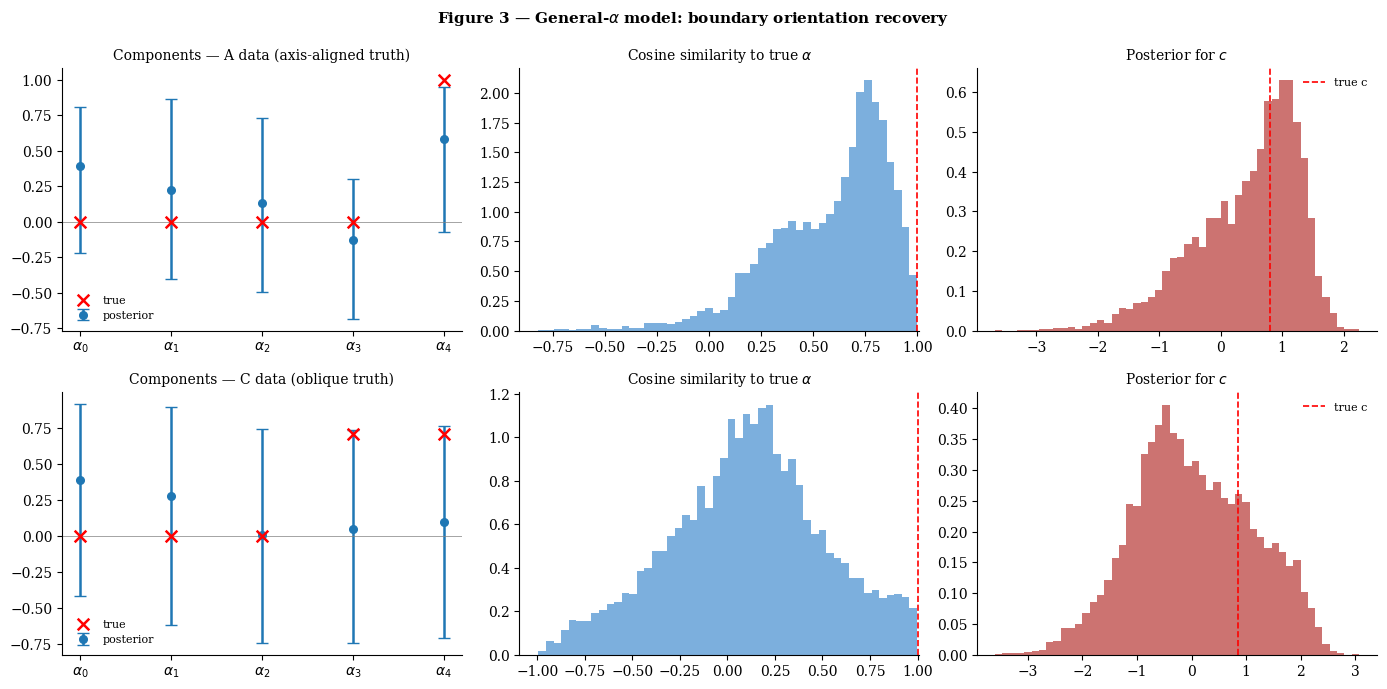

In [11]:
# Safe high-replication version: existing dissertation artefacts are left untouched.
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for row, (res, a_true, ttl) in enumerate([
        (resGA, alpha_A_true, 'A data (axis-aligned truth)'),
        (resGC, alpha_C,      'C data (oblique truth)')]):
    ax = axes[row, 0]
    means = res['alpha'].mean(axis=0)
    lo = np.percentile(res['alpha'], 2.5, axis=0); hi = np.percentile(res['alpha'], 97.5, axis=0)
    xs = np.arange(P_SIM)
    ax.errorbar(xs, means, yerr=[means-lo, hi-means], fmt='o', capsize=4, label='posterior')
    ax.scatter(xs, a_true, marker='x', color='red', s=70, zorder=3, label='true')
    ax.axhline(0, color='grey', lw=0.5); ax.set_xticks(xs)
    ax.set_xticklabels([f'$\\alpha_{j}$' for j in range(P_SIM)])
    ax.set_title(f'Components — {ttl}', fontsize=10); ax.legend(fontsize=8, frameon=False)

    ax = axes[row, 1]
    ax.hist(res['cos'], bins=50, color='#5B9BD5', alpha=0.8, density=True)
    ax.axvline(1.0, color='red', ls='--', lw=1.2)
    ax.set_title('Cosine similarity to true $\\alpha$', fontsize=10)
    ax.set_xlim(right=1.01)

    ax = axes[row, 2]
    ax.hist(res['c'], bins=50, color='#C0504D', alpha=0.8, density=True)
    ax.axvline(TRUE_C if row == 0 else c_C, color='red', ls='--', lw=1.2, label='true c')
    ax.set_title('Posterior for $c$', fontsize=10); ax.legend(fontsize=8, frameon=False)

fig.suptitle('Figure 3 — General-$\\alpha$ model: boundary orientation recovery',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()


In [12]:
# Contraction check: same generative process, more information (larger n)
N_BIG = 6000
rng_big = np.random.default_rng(SEED + 99)
X_big, y_big, _ = logistic_dgp(N_BIG, rng_big, p=P_SIM)
region_big = X_big[:, 4] > TRUE_C
y_corr_big, flips_big = corrupt(y_big, region_big, P_IN, seed=SEED + 99)
print(f'n={N_BIG}: corrupted {flips_big.sum()} ({flips_big.mean()*100:.1f}%)')

data_big = {'n': N_BIG, 'p': P_SIM, 'X': X_big.tolist(), 'y': y_corr_big.tolist(),
            'kappa': 5.0, 'c_prior_mean': 0.0, 'c_prior_sd': 1.0}
fitGA_big = model_gen.sample(data=data_big, chains=4, parallel_chains=4,
                             iter_warmup=1000, iter_sampling=2000, seed=SEED,
                             adapt_delta=0.99, max_treedepth=12, show_progress=False)
resGA_big = summarise_general(fitGA_big, flips_big, y_corr_big, alpha_A_true, TRUE_C,
                              f'General alpha — axis-aligned truth, n={N_BIG}')


14:57:03 - cmdstanpy - INFO - CmdStan start processing
14:57:03 - cmdstanpy - INFO - Chain [1] start processing
14:57:03 - cmdstanpy - INFO - Chain [2] start processing
14:57:03 - cmdstanpy - INFO - Chain [3] start processing
14:57:03 - cmdstanpy - INFO - Chain [4] start processing


n=6000: corrupted 179 (3.0%)


14:58:37 - cmdstanpy - INFO - Chain [4] done processing
14:58:46 - cmdstanpy - INFO - Chain [1] done processing
14:58:50 - cmdstanpy - INFO - Chain [3] done processing
14:59:04 - cmdstanpy - INFO - Chain [2] done processing



===== General alpha — axis-aligned truth, n=6000 =====
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

  alpha[0] [+0.000]: mean=-0.113 95% CI [-0.253, +0.024]
  alpha[1] [+0.000]: mean=+0.010 95% CI [-0.109, +0.123]
  alpha[2] [+0.000]: mean=+0.027 95% CI [-0.083, +0.135]
  alpha[3] [+0.000]: mean=+0.134 95% CI [+0.013, +0.249]
  alpha[4] [+1.000]: mean=+0.976 95% CI [+0.945, +0.995]
  c [+0.80]: mean=+0.765 95% CI [+0.539, +0.985]
  q [+0.35]: mean=+0.396 95% CI [+0.312, +0.478]
  cosine(alpha_draw, alpha_true): mean=0.976 5th pct=0.952
  localisation AUC (negatives only): 0.960


### General-model check

Learning the full boundary direction is harder than estimating a threshold along a supplied axis.

At the smaller sample size, the orientation posterior can remain diffuse even when observation-level localisation is still useful. The larger-sample fit checks whether additional information produces stronger concentration around the true direction.

This separates two questions: whether the exact geometry is recovered, and whether the model can still rank genuinely corrupted observations.


## Soft-boundary sensitivity

The simulated corruption mechanism is hard, while the Stan fit uses a smooth approximation.

The model is refitted using

$$
\kappa\in\{3,5,10\}
$$

to check whether the main recovery and localisation results depend strongly on the chosen steepness.

This is a computational sensitivity check, not a comparison of different scientific corruption mechanisms.


In [13]:
if STAN_AVAILABLE:
    cfg = cfgA; neg = cfg['y_corr'] == 0
    for k_val in [3.0, 5.0, 10.0]:
        fk = fit_stan(X_sim, cfg['y_corr'], boundary_dim=4, kappa=k_val)
        zp = fk.stan_variable('z_prob').mean(axis=0)
        print(f'kappa={k_val:5.1f}: E[c]={fk.stan_variable("c").mean():+.3f}  '
              f'E[q]={fk.stan_variable("q").mean():.3f}  '
              f'loc AUC={roc_auc_score(cfg["flips"][neg], zp[neg]):.3f}')


15:00:20 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

...

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

15:00:55 - cmdstanpy - INFO - CmdStan done processing.



kappa= 10.0: E[c]=+0.850  E[q]=0.331  loc AUC=0.981


## Comparison with alternative detectors

Posterior corruption probabilities are compared with confident learning and a shallow decision tree.

The comparison is restricted to observed negatives, since these are the only labels eligible for corruption under the one-sided mechanism. Performance is summarised using ranked AUC and precision at $k$, where $k$ is the true number of corruptions.

Because the simulated data are generated from a mechanism close to the Bayesian model, this comparison is a validation benchmark rather than evidence of universal superiority.


In [14]:
from cleanlab.rank import get_label_quality_scores

if STAN_AVAILABLE:
    cfg, res = cfgA, resA
    y_c = cfg['y_corr']; flips = cfg['flips']; neg = y_c == 0
    k_true = int(flips.sum())

    sc = StandardScaler(); Xs = sc.fit_transform(X_sim)
    pp = cross_val_predict(LogisticRegression(max_iter=500, class_weight='balanced',
                                              random_state=SEED),
                           Xs, y_c.astype(int), cv=3, method='predict_proba')
    cl_score = 1.0 - get_label_quality_scores(labels=y_c.astype(int), pred_probs=pp)

    dt = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(X_sim, y_c)
    tree_score = dt.predict_proba(X_sim)[:, 1]

    scores = {'Stan z_prob': res['z_mean'], 'CleanLab': cl_score, 'Tree P(y=1)': tree_score}
    print(f'True corruptions among negatives: {k_true}\n')
    print(f'{"Method":<14} {"ranked AUC":>11} {"precision@k":>12}')
    print('-' * 40)
    for name, s in scores.items():
        auc = roc_auc_score(flips[neg], s[neg])
        top = np.argsort(-s[neg])[:k_true]
        prec = flips[neg][top].mean()
        print(f'{name:<14} {auc:>11.3f} {prec:>12.3f}')


True corruptions among negatives: 44

Method          ranked AUC  precision@k
----------------------------------------
Stan z_prob          0.978        0.682
CleanLab             0.860        0.341
Tree P(y=1)          0.827        0.227


## Individual posterior corruption probabilities

For each observed negative, the Bayesian model returns

$$
P(z_i=1\mid\mathcal{D}),
$$

which averages uncertainty over the response model, corruption rate and boundary parameters.

The highest-ranked observations are compared with the known simulation truth below. The reported 2.5--97.5% ranges describe variation in the conditional corruption probability across posterior draws.


In [15]:
import pandas as pd

if STAN_AVAILABLE:
    z_draws = fitA.stan_variable('z_prob')          # (draws, N)
    z_mean  = z_draws.mean(axis=0)
    z_lo    = np.percentile(z_draws, 2.5, axis=0)
    z_hi    = np.percentile(z_draws, 97.5, axis=0)

    top = np.argsort(z_mean)[::-1][:15]
    df = pd.DataFrame({
        'Observation':         top,
        'P(z_i=1 | data)':     z_mean[top].round(3),
        '95% CI lower':        z_lo[top].round(3),
        '95% CI upper':        z_hi[top].round(3),
        'x_5 (boundary var)':  X_sim[top, 4].round(2),
        'Observed label':      cfgA['y_corr'][top],
        'Truly corrupted':     cfgA['flips'][top],
    })
    display(df)

    n_top = cfgA['flips'][top].sum()
    print(f'\nOf the 15 highest-probability individuals, {n_top} are truly corrupted.')
    i = top[0]
    print(f'Example statement: individual {i} has posterior corruption probability '
          f'{z_mean[i]:.2f}. Across posterior draws, the conditional probability '
          f'has a 2.5%--97.5% range [{z_lo[i]:.2f}, {z_hi[i]:.2f}].')


,Observation,P(z_i=1 | data),95% CI lower,95% CI upper,x_5 (boundary var),Observed label,Truly corrupted
0,1073,0.944,0.870,0.980,1.78,0,True
1,248,0.900,0.778,0.962,1.04,0,True
2,465,0.886,0.749,0.956,1.00,0,True
3,618,0.848,0.699,0.932,1.83,0,True
4,263,0.847,0.699,0.933,1.19,0,True
5,332,0.828,0.663,0.926,1.19,0,True
6,1270,0.810,0.645,0.912,1.56,0,True
7,953,0.796,0.623,0.902,1.60,0,True
8,990,0.782,0.599,0.896,1.12,0,True
9,1091,0.760,0.524,0.898,0.90,0,True



Of the 15 highest-probability individuals, 13 are truly corrupted.
Example statement: individual 1073 has posterior corruption probability 0.94. Across posterior draws, the conditional probability has a 2.5%--97.5% range [0.87, 0.98].


## Summary

The supplied-direction fits test recovery when part of the corruption geometry is known, while the general model shows the additional difficulty of estimating the boundary orientation.

The larger-sample fit checks how geometric recovery changes with more information, and the $\kappa$ analysis checks that the conclusions are not driven by one soft-boundary approximation.

The comparison methods provide a benchmark for localisation, while the Bayesian model additionally returns posterior probabilities of corruption for individual observations.

Chapter 1 keeps the underlying framework fixed and varies the data-generating conditions more systematically to investigate when recovery and localisation succeed or fail.



# High-replication validation

Nick's replication feedback is applied here only to the quantitative validation claims that
would otherwise rest on a single simulated dataset.

- Configuration A: supplied boundary on a null response predictor — 20 independent datasets.
- Configuration B: supplied boundary on the strongest response predictor — 20 independent datasets.
- Soft-boundary sensitivity: \(\kappa\in\{3,5,10\}\) — paired across the same 20 Configuration-A worlds.

The general learned-boundary checks above remain implementation checks. Their systematic
between-dataset behaviour is investigated in the replicated learned-boundary study in Chapter 1.

Each completed fit is checkpointed immediately. Re-running this section skips completed fits.


In [ ]:

# ------------------------------------------------------------------
# Replication controls and checkpoint helpers
# ------------------------------------------------------------------
VALIDATION_REPS = 20
KAPPA_VALUES = [3.0, 5.0, 10.0]

def _token(x):
    return str(x).replace(".", "p").replace("-", "m").replace(" ", "")

def validation_checkpoint(config, rep, kappa):
    return CHECKPOINT_DIR / (
        f"validation__config-{config}__rep-{rep:02d}__kappa-{_token(kappa)}.csv"
    )

def _diagnostic_summary(fit):
    s = fit.summary()
    core_mask = (
        (s.index == "beta0")
        | (s.index == "c")
        | (s.index == "q")
        | s.index.str.startswith("beta[")
    )
    core = s.loc[core_mask]

    max_rhat = float(
        core["R_hat"].replace([np.inf, -np.inf], np.nan).max()
    )
    min_ess = float(
        core["ESS_bulk"].replace([np.inf, -np.inf], np.nan).min()
    )

    mv = fit.method_variables()
    divergences = int(
        np.asarray(mv.get("divergent__", np.array([0]))).sum()
    )
    td = np.asarray(mv.get("treedepth__", np.array([])))
    treedepth_hits = int((td >= 12).sum()) if td.size else 0

    passed = (
        max_rhat <= 1.05
        and min_ess >= 100
        and divergences == 0
        and treedepth_hits == 0
    )
    return {
        "max_rhat": max_rhat,
        "min_ess_bulk": min_ess,
        "divergences": divergences,
        "max_treedepth_hits": treedepth_hits,
        "diagnostics_pass": passed,
    }

def _validation_metrics(
    fit,
    X,
    y_obs,
    flips,
    region,
    boundary_dim,
    config_name,
    rep,
    seed,
    kappa,
):
    beta0 = fit.stan_variable("beta0")
    beta = fit.stan_variable("beta")
    c_post = fit.stan_variable("c")
    q_post = fit.stan_variable("q")
    z_mean = fit.stan_variable("z_prob").mean(axis=0)

    neg = (y_obs == 0)
    k_true = int(flips.sum())

    if len(np.unique(flips[neg])) == 2:
        auc = roc_auc_score(flips[neg], z_mean[neg])
    else:
        auc = np.nan

    if k_true > 0:
        top = np.argsort(-z_mean[neg])[:k_true]
        precision_k = float(flips[neg][top].mean())
    else:
        precision_k = np.nan

    beta_truth = np.zeros(X.shape[1])
    beta_truth[:min(4, X.shape[1])] = [1.5, -1.2, 0.8, -0.6][:min(4, X.shape[1])]
    beta_mean = beta.mean(axis=0)

    row = {
        "config": config_name,
        "rep": rep,
        "seed": seed,
        "kappa": kappa,
        "n": len(y_obs),
        "region_share": float(region.mean()),
        "eligible_positives": int(((region) & (y_true_rep == 1)).sum()),
        "n_corrupted": int(flips.sum()),
        "effective_flip_rate": float(flips.mean()),
        "beta0_mean": float(beta0.mean()),
        "beta0_abs_error": float(abs(beta0.mean() - (-0.8))),
        "beta_rmse": float(np.sqrt(np.mean((beta_mean - beta_truth) ** 2))),
        "c_mean": float(c_post.mean()),
        "c_abs_error": float(abs(c_post.mean() - TRUE_C)),
        "q_mean": float(q_post.mean()),
        "q_abs_error": float(abs(q_post.mean() - P_IN)),
        "localisation_auc": float(auc),
        "precision_at_k": float(precision_k),
    }
    row.update(_diagnostic_summary(fit))
    return row

print(
    f"High-rep validation configured for {VALIDATION_REPS} independent datasets; "
    f"kappa values = {KAPPA_VALUES}"
)


In [ ]:

# ------------------------------------------------------------------
# Run Configurations A/B and paired kappa sensitivity.
# ------------------------------------------------------------------
if not STAN_AVAILABLE:
    raise RuntimeError("Stan is required for the high-replication validation.")

highrep_rows = []

for rep in range(VALIDATION_REPS):
    # A completely new independently generated dataset for each replicate.
    data_seed = SEED + 100_000 + rep
    rng_rep = np.random.default_rng(data_seed)
    X_rep, y_true_rep, _ = logistic_dgp(N_SIM, rng_rep, p=P_SIM)

    for config_name, boundary_dim in [("A", 4), ("B", 0)]:
        region_rep = X_rep[:, boundary_dim] > TRUE_C

        # Deterministic but independent corruption draw for this config/replicate.
        corruption_seed = data_seed + 1000 + boundary_dim
        y_obs_rep, flips_rep = corrupt(
            y_true_rep,
            region_rep,
            P_IN,
            seed=corruption_seed,
        )

        # Configuration A is also used for the paired kappa sensitivity.
        kappas = KAPPA_VALUES if config_name == "A" else [KAPPA]

        for kappa in kappas:
            ckpt = validation_checkpoint(config_name, rep, kappa)

            if ckpt.exists():
                row = pd.read_csv(ckpt).iloc[0].to_dict()
                highrep_rows.append(row)
                print(
                    f"Config {config_name} | rep {rep+1}/{VALIDATION_REPS} | "
                    f"kappa={kappa:g} | checkpoint found"
                )
                continue

            fit_seed = data_seed + 10_000 + int(100 * kappa) + boundary_dim
            print(
                f"Config {config_name} | rep {rep+1}/{VALIDATION_REPS} | "
                f"kappa={kappa:g} | corruptions={flips_rep.sum()}"
            )

            fit_rep = fit_stan(
                X_rep,
                y_obs_rep,
                boundary_dim=boundary_dim,
                kappa=kappa,
                seed=fit_seed,
            )

            row = _validation_metrics(
                fit_rep,
                X_rep,
                y_obs_rep,
                flips_rep,
                region_rep,
                boundary_dim,
                config_name,
                rep,
                data_seed,
                kappa,
            )

            pd.DataFrame([row]).to_csv(ckpt, index=False)
            highrep_rows.append(row)

            del fit_rep
            gc.collect()

validation_highrep = pd.DataFrame(highrep_rows)

validation_highrep.to_csv(
    RESULT_DIR / "highrep_validation_all_replicates.csv",
    index=False,
)

print("Saved:", RESULT_DIR / "highrep_validation_all_replicates.csv")
display(validation_highrep.head())


In [ ]:

# ------------------------------------------------------------------
# Summaries: A/B comparison at kappa=5 and paired kappa sensitivity.
# ------------------------------------------------------------------
ab = validation_highrep[
    np.isclose(validation_highrep["kappa"].astype(float), 5.0)
].copy()

ab_summary = (
    ab.groupby("config", as_index=False)
      .agg(
          n_reps=("rep", "count"),
          diagnostic_pass_rate=("diagnostics_pass", "mean"),
          localisation_auc_mean=("localisation_auc", "mean"),
          localisation_auc_sd=("localisation_auc", "std"),
          precision_at_k_mean=("precision_at_k", "mean"),
          precision_at_k_sd=("precision_at_k", "std"),
          beta_rmse_mean=("beta_rmse", "mean"),
          beta_rmse_sd=("beta_rmse", "std"),
          c_error_mean=("c_abs_error", "mean"),
          c_error_sd=("c_abs_error", "std"),
          q_error_mean=("q_abs_error", "mean"),
          q_error_sd=("q_abs_error", "std"),
          corruptions_mean=("n_corrupted", "mean"),
          corruptions_sd=("n_corrupted", "std"),
      )
)

kappa_df = validation_highrep[
    validation_highrep["config"].astype(str).eq("A")
].copy()

kappa_summary = (
    kappa_df.groupby("kappa", as_index=False)
            .agg(
                n_reps=("rep", "count"),
                diagnostic_pass_rate=("diagnostics_pass", "mean"),
                localisation_auc_mean=("localisation_auc", "mean"),
                localisation_auc_sd=("localisation_auc", "std"),
                c_mean=("c_mean", "mean"),
                c_sd=("c_mean", "std"),
                q_mean=("q_mean", "mean"),
                q_sd=("q_mean", "std"),
                c_error_mean=("c_abs_error", "mean"),
                q_error_mean=("q_abs_error", "mean"),
            )
)

ab_summary.to_csv(
    RESULT_DIR / "highrep_validation_A_B_summary.csv",
    index=False,
)
kappa_summary.to_csv(
    RESULT_DIR / "highrep_kappa_sensitivity_summary.csv",
    index=False,
)

print("Configuration A/B replicated summary")
display(ab_summary)

print("Paired kappa-sensitivity replicated summary")
display(kappa_summary)


In [ ]:

# ------------------------------------------------------------------
# Between-dataset variability figures: mean ± one SD.
# These bars describe variation across independently generated datasets.
# They are not confidence intervals for the mean.
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

x = np.arange(len(ab_summary))
labels = ab_summary["config"].astype(str).tolist()

for ax, mean_col, sd_col, ylabel, title in [
    (
        axes[0],
        "localisation_auc_mean",
        "localisation_auc_sd",
        "Localisation AUC",
        "Observation-level localisation",
    ),
    (
        axes[1],
        "c_error_mean",
        "c_error_sd",
        r"Absolute error in $c$",
        "Threshold recovery",
    ),
    (
        axes[2],
        "q_error_mean",
        "q_error_sd",
        r"Absolute error in $q$",
        "Corruption-rate recovery",
    ),
]:
    ax.errorbar(
        x,
        ab_summary[mean_col],
        yerr=ab_summary[sd_col],
        fmt="o",
        capsize=4,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Configuration")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

fig.suptitle(
    "Replicated framework validation: mean ± between-dataset SD",
    y=1.02,
)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "highrep_validation_A_B_errorbars.png",
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "highrep_validation_A_B_errorbars.pdf",
    bbox_inches="tight",
)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0))

axes[0].errorbar(
    kappa_summary["kappa"],
    kappa_summary["localisation_auc_mean"],
    yerr=kappa_summary["localisation_auc_sd"],
    marker="o",
    capsize=4,
)
axes[0].set_xlabel(r"Soft-boundary steepness $\kappa$")
axes[0].set_ylabel("Localisation AUC")
axes[0].set_title("Localisation sensitivity")

axes[1].errorbar(
    kappa_summary["kappa"],
    kappa_summary["q_mean"],
    yerr=kappa_summary["q_sd"],
    marker="o",
    capsize=4,
    label=r"$q$",
)
axes[1].axhline(P_IN, linestyle="--", label="True q")
axes[1].set_xlabel(r"Soft-boundary steepness $\kappa$")
axes[1].set_ylabel(r"Posterior mean $q$")
axes[1].set_title("Corruption-rate sensitivity")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    FIG_DIR / "highrep_kappa_sensitivity_errorbars.png",
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "highrep_kappa_sensitivity_errorbars.pdf",
    bbox_inches="tight",
)
plt.show()


In [ ]:

# ------------------------------------------------------------------
# Nick's running-average check:
# How many independent datasets are needed before reported quantities settle?
# ------------------------------------------------------------------
running_rows = []

for config in ["A", "B"]:
    d = (
        ab[ab["config"].astype(str).eq(config)]
        .sort_values("rep")
        .copy()
    )
    d["replicate_count"] = np.arange(1, len(d) + 1)
    d["running_auc"] = d["localisation_auc"].expanding().mean()
    d["running_c_error"] = d["c_abs_error"].expanding().mean()
    d["running_q_error"] = d["q_abs_error"].expanding().mean()

    running_rows.append(
        d[
            [
                "config",
                "replicate_count",
                "running_auc",
                "running_c_error",
                "running_q_error",
            ]
        ]
    )

validation_running = pd.concat(running_rows, ignore_index=True)
validation_running.to_csv(
    RESULT_DIR / "highrep_validation_running_means.csv",
    index=False,
)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0))

for config, d in validation_running.groupby("config"):
    axes[0].plot(
        d["replicate_count"],
        d["running_auc"],
        marker="o",
        markersize=3,
        label=f"Config {config}",
    )
    axes[1].plot(
        d["replicate_count"],
        d["running_c_error"],
        marker="o",
        markersize=3,
        label=f"Config {config}",
    )
    axes[2].plot(
        d["replicate_count"],
        d["running_q_error"],
        marker="o",
        markersize=3,
        label=f"Config {config}",
    )

axes[0].set_ylabel("Running mean localisation AUC")
axes[1].set_ylabel(r"Running mean $|c-\hat c|$")
axes[2].set_ylabel(r"Running mean $|q-\hat q|$")

for ax in axes:
    ax.set_xlabel("Number of independent datasets")
    ax.legend()

fig.suptitle("Replicate stability of framework-validation summaries", y=1.02)
plt.tight_layout()
plt.savefig(
    FIG_DIR / "highrep_validation_running_means.png",
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    FIG_DIR / "highrep_validation_running_means.pdf",
    bbox_inches="tight",
)
plt.show()
